## Resident Advisor Reviews
Loads RA reviews from a local CSV file.


In [1]:
# Imports and file path config.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("../datasets")
RA_PATH = Path("/Users/jamesemcnally/Dropbox/DLBC/resident-advisor.csv")


## Loading Data


In [2]:
# Load CSV and preview basic info.
df = pd.read_csv(RA_PATH)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15695 entries, 0 to 15694
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          15693 non-null  object 
 1   author         15695 non-null  object 
 2   date           15695 non-null  object 
 3   genre          15060 non-null  object 
 4   rating         15695 non-null  float64
 5   review         15695 non-null  object 
 6   ra_recommends  15695 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 858.4+ KB


In [3]:
# Quick look at the first two rows.
df.head(2)


,title,author,date,genre,rating,review,ra_recommends
0,GU:019 - John Digweed - LA,Robbie Y,2001-02-21,progressivehouse,5.0,Global Underground 19 has been out in stores ...,0
1,Nubreed:005 - Lee Burridge,Robbie Y,2001-07-23,progressivehouse,4.5,The Nubreed series has undoubtedly been one o...,0


## Data Cleaning


In [4]:
# Convert date to datetime, drop duplicates, drop rows with missing reviews or ratings.
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df.drop_duplicates(subset=["review"])
df = df.dropna(subset=["review", "rating"])
print(f"{len(df):,} reviews after cleaning")


15,684 reviews after cleaning


In [5]:
# Split RA 'title' column (format: "Artist - Album") into separate artist and album columns.
# Uses n=1 split so multi-dash titles keep the full remainder in 'album'.
# Strips whitespace to clean up double-dash typo artifacts (e.g. "DJ Sotofett / SVN -  - ...").

title_pos = df.columns.get_loc("title")
split = df["title"].str.split(" - ", n=1, expand=True)
df.insert(title_pos,     "artist", split[0].str.strip())
df.insert(title_pos + 1, "album",  split[1].str.strip())
df = df.drop(columns=["title"])

no_sep = split[1].isna().sum()
if no_sep:
    print(f"Note: {no_sep} entries had no ' - ' separator; album set to NaN for those rows")
print(df[["artist", "album"]].head(10))
print(f"\n{len(df):,} rows total")

Note: 430 entries had no ' - ' separator; album set to NaN for those rows
                                    artist              album
0                                   GU:019  John Digweed - LA
1                              Nubreed:005       Lee Burridge
2                                Bedrock 2        Jimmy Van M
3                              Transport 4         Max Graham
4  Danny Howells : Nocturnal Frequencies 3               None
5                          Ashley Casselle         Deviations
6                                   Desire        Dave Seaman
7                             Steve Lawler       Dark Drums 2
8                                     Cass    Prologue - Fire
9                          Jody Wisternoff      Way Out There

15,684 rows total


## Cleaning Text


In [6]:
# Strip HTML tags, fix whitespace.
import html, re

df["cleaned_review"] = df["review"].str.replace(r"<[^>]+>", "", regex=True)
df["cleaned_review"] = df["cleaned_review"].apply(html.unescape)
df["cleaned_review"] = df["cleaned_review"].str.replace(r"\s+", " ", regex=True).str.strip()


## Basic Text Analysis


In [7]:
# Add word count, character count, sentence count, and TextBlob sentiment.
from textblob import TextBlob

df["word_count"] = df["cleaned_review"].str.split().str.len()
df["char_count"] = df["cleaned_review"].str.len()
df["sentence_count"] = df["cleaned_review"].str.count(r"\.")
df["sentiment_score"] = df["cleaned_review"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["sentiment_category"] = df["sentiment_score"].apply(lambda x: "positive" if x > 0 else "negative" if x < 0 else "neutral")


### Length Distributions


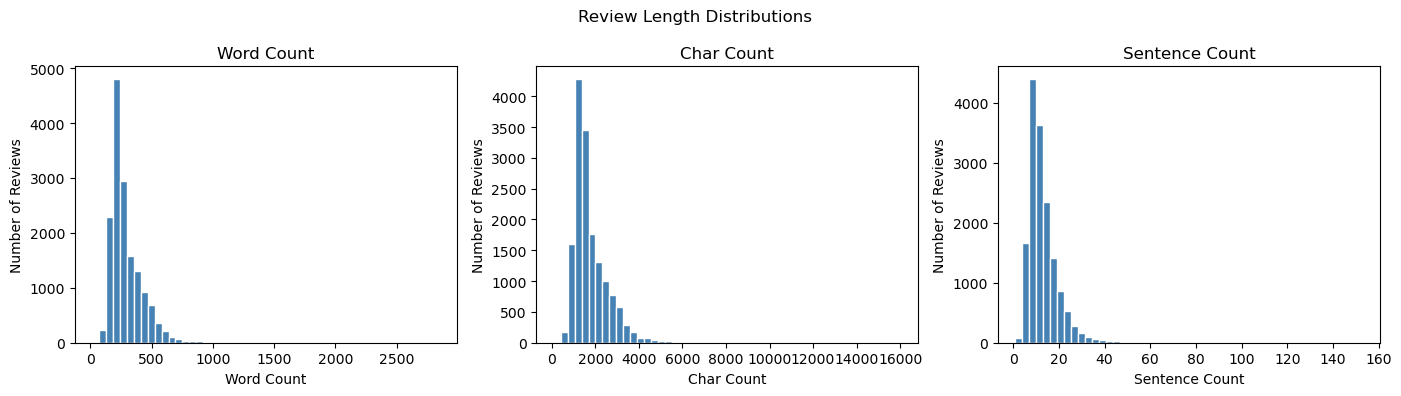

In [8]:
# Histograms of word count, character count, and sentence count.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["word_count", "char_count", "sentence_count"]):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Number of Reviews")

fig.suptitle("Review Length Distributions")
fig.tight_layout()
plt.show()


### Score Distribution


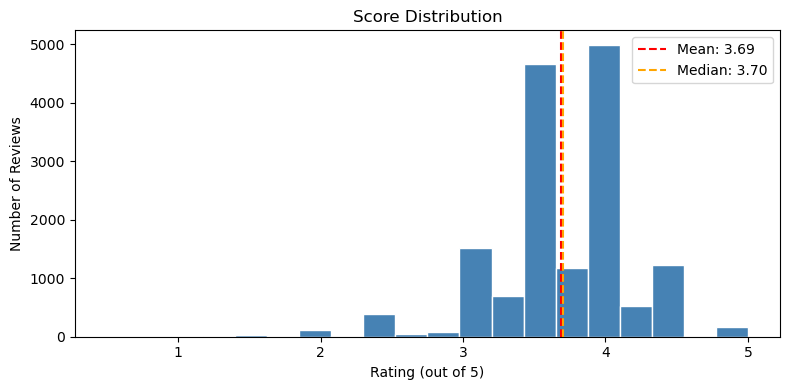

In [9]:
# Histogram of RA ratings (out of 5) with mean and median marked.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["rating"], bins=20, color="steelblue", edgecolor="white")
ax.axvline(df["rating"].mean(), color="red", linestyle="--", label=f"Mean: {df['rating'].mean():.2f}")
ax.axvline(df["rating"].median(), color="orange", linestyle="--", label=f"Median: {df['rating'].median():.2f}")
ax.set_title("Score Distribution")
ax.set_xlabel("Rating (out of 5)")
ax.set_ylabel("Number of Reviews")
ax.legend()
plt.tight_layout()
plt.show()


### Reviews per Year


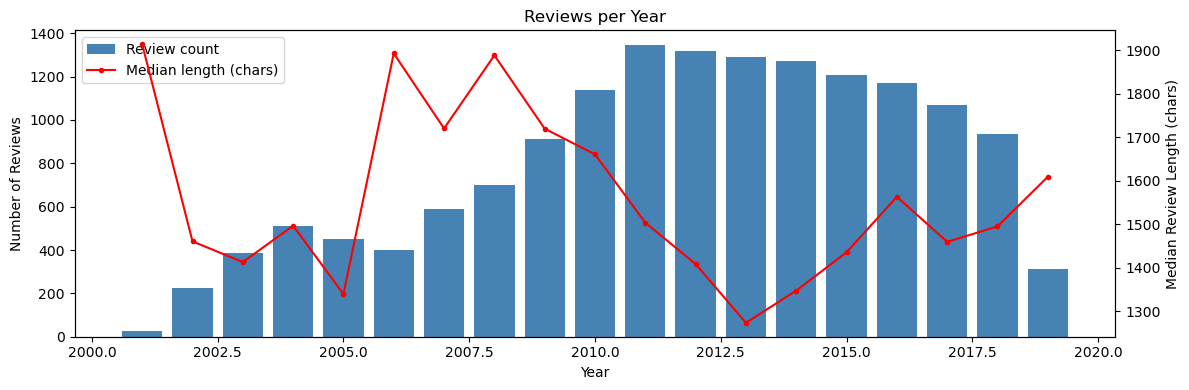

In [10]:
# Bar chart of review count per year, overlaid with median review length trend.
yearly = (
    df.assign(year=pd.to_datetime(df["date"]).dt.year)
    .groupby("year")
    .agg(review_count=("album", "count"), median_chars=("char_count", "median"))
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(yearly.index, yearly["review_count"], color="steelblue", label="Review count")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Reviews")
ax1.set_title("Reviews per Year")

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly["median_chars"], color="red", marker="o", markersize=3, label="Median length (chars)")
ax2.set_ylabel("Median Review Length (chars)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


### Genre Distribution


Unique genres: 52

All genres:
house, techno, experimental, techhouse, electro, minimal, ambient, deephouse, disco, Not Listed, dubstep, bass, breakbeat, pop, progressivehouse, hiphop, dub, downtempo, drumandbass, dubtechno, grime, acid, garage, funksoul, industrial, idm, jazz, club, trance, footwork, jungle, noise, balearic, drone, rnb, classical, italodisco, ebm, newwave, ukfunky, brokenbeat, postpunk, dancehall, hardcore, krautrock, breakcore, kuduro, gqom, bailefunk, vaporwave, afrobeat, kwaito


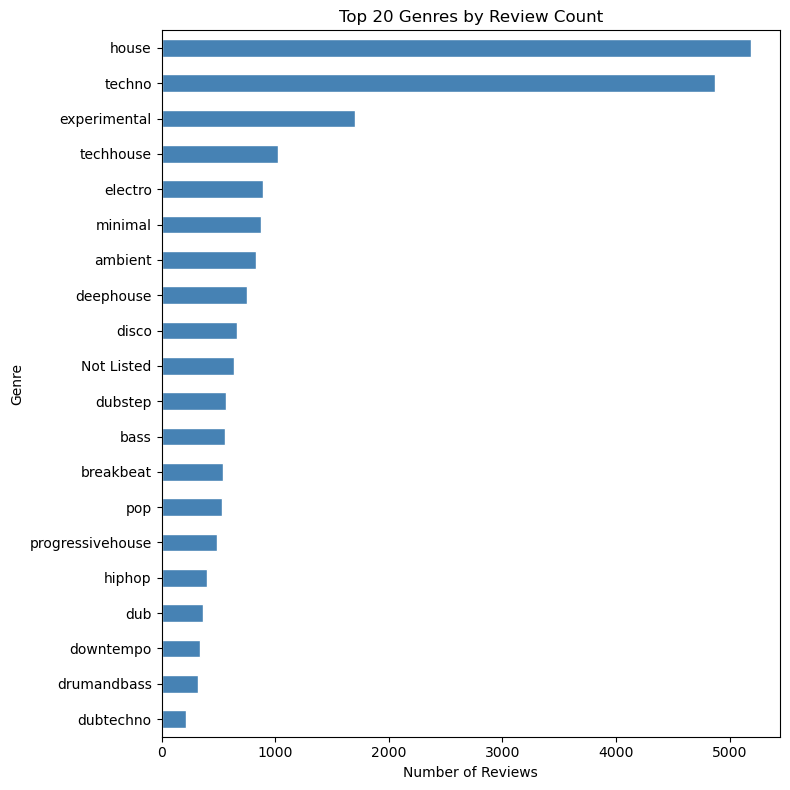

In [11]:
# Bar chart of top 20 genres; prints total unique genre count and full genre list.
genre_counts = (
    df["genre"].fillna("Not Listed")
    .str.split(", ")
    .explode()
    .str.strip()
    .value_counts()
)

print(f"Unique genres: {len(genre_counts)}")
print("\nAll genres:")
print(", ".join(genre_counts.index.tolist()))

fig, ax = plt.subplots(figsize=(8, 8))
genre_counts.head(20).plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 Genres by Review Count")
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Genre")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Reviews per Author


Unique authors: 523
Reviews per author — mean: 30.0, median: 3, max: 1843
Top 10 authors account for 39.1% of all reviews
Authors with only 1 review: 188 (35.9% of authors)


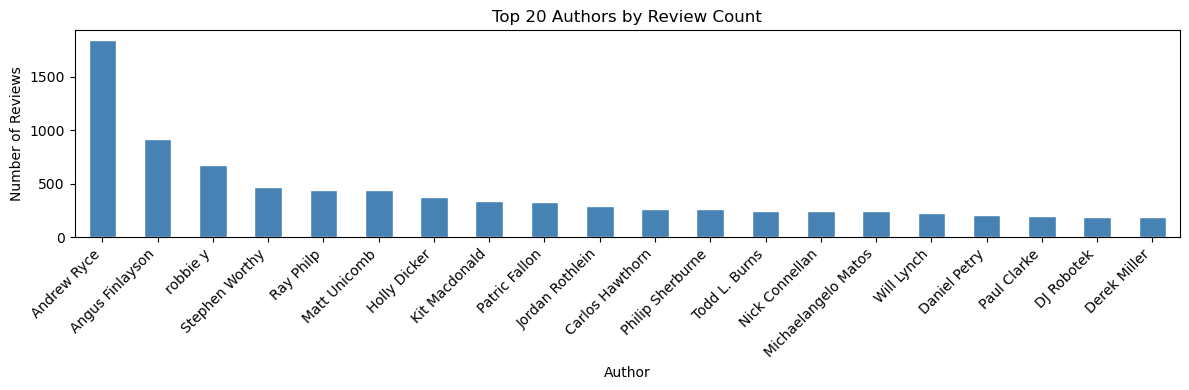

In [12]:
# Summary stats on author distribution and bar chart of top 20 most prolific reviewers.
author_counts = df["author"].value_counts()

print(f"Unique authors: {len(author_counts):,}")
print(f"Reviews per author — mean: {author_counts.mean():.1f}, median: {author_counts.median():.0f}, max: {author_counts.max()}")
print(f"Top 10 authors account for {author_counts.head(10).sum() / len(df) * 100:.1f}% of all reviews")
print(f"Authors with only 1 review: {(author_counts == 1).sum():,} ({(author_counts == 1).sum() / len(author_counts) * 100:.1f}% of authors)")

fig, ax = plt.subplots(figsize=(12, 4))
author_counts.head(20).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 Authors by Review Count")
ax.set_xlabel("Author")
ax.set_ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### TF-IDF Top Terms by Genre


In [13]:
# TF-IDF top terms by genre: standard stopwords, then with music-review vocabulary removed.
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

genre_texts = (
    df[df["genre"].notna() & ~df["genre"].str.contains(",", na=False)]
    .groupby("genre")["cleaned_review"]
    .apply(" ".join)
)

def print_tfidf(title, vectorizer):
    matrix = vectorizer.fit_transform(genre_texts)
    terms = vectorizer.get_feature_names_out()
    print(f"\n{title}")
    print(f"{'Genre':<20} Top terms")
    print("-" * 80)
    for i, genre in enumerate(genre_texts.index):
        top = np.argsort(matrix[i].toarray()[0])[::-1][:8]
        print(f"{genre:<20} {', '.join(terms[top])}")

print_tfidf(
    "Standard stopwords",
    TfidfVectorizer(max_features=5000, stop_words="english")
)

custom_stopwords = list(TfidfVectorizer(stop_words="english").get_stop_words()) + [
    "album", "music", "song", "songs", "track", "tracks", "sound", "sounds",
    "like", "just", "band", "new", "time", "work", "one", "make", "way"
]
print_tfidf(
    "Music-review stopwords removed",
    TfidfVectorizer(max_features=5000, stop_words=custom_stopwords)
)



Standard stopwords
Genre                Top terms
--------------------------------------------------------------------------------
acid                 acid, 303, house, music, like, sound, track, tracks
afrobeat             tony, jon, music, honest, von, bongos, early, mark
ambient              music, like, ambient, album, sound, tracks, new, track
balearic             like, balearic, guitar, island, album, sketches, music, silver
bass                 like, bass, music, track, sound, tracks, album, sounds
breakbeat            breaks, breakbeat, tune, mix, remix, track, vocal, bass
breakcore            dear, classical, album, like, bit, love, breaks, idm
brokenbeat           broken, beat, tracks, vocals, london, like, rude, music
classical            music, classical, piano, herbert, recording, album, blue, eno
club                 club, jersey, like, drums, track, label, new, ep
dancehall            dancehall, martin, like, miss, red, sound, album, reggae
deephouse            house, 

## Save Cleaned Data


In [14]:
# Filter to reviews with at least 200 characters and save to CSV.
df_clean = df[df["char_count"] >= 200].copy()
df_clean.to_csv(DATA_DIR / "resident_advisor_reviews_cleaned.csv", index=False)
print(f"Saved {len(df_clean):,} reviews to {DATA_DIR / 'resident_advisor_reviews_cleaned.csv'}")


Saved 15,681 reviews to ../datasets/resident_advisor_reviews_cleaned.csv
